# July 2026 canonical forecast — FINAL (2026-07-06, both platforms)

Stakeholder-facing canonical view: Desktop & Mobile 2026 DAU on a 28-day MA, **current (July)** vs
**prior (June delivered)**, with the Dec-15 measurement markers. Ported from
`data-official/2026-06/june_canonical_v2026-05-27.ipynb`.

There is **one forecast per platform**, and **both are re-anchored to forecast_start 2026-07-06**
(trained through the latest complete day, 2026-07-05 — a consistent seam). Iran is included like any
other country — queried natively; the 2026-03-01→05-25 shutdown gap is covered by mozaic's built-in
counterfactual fill (trains on the counterfactual, keeps real actuals). Not a separate series.

**Every known DAU influence is in place. Final Dec-15 2026 28d-MA (headwind applied):**
**Desktop 48,585,483 · Mobile 17,923,869 · ALL 66,509,352.**

- **Desktop** — the LOCKED parameter-search model (`desktop_locked/`): `cps=0.08983, cpr=0.65,
  holiday_threshold=−0.032 (center)` with the launch-on-login (`l`, 125K flat cap) + MozillaOnline
  (`o`, Brad's official CN migration model) overlays, both bidirectional on legacy_desktop
  `modern_windows` DAU. Supersedes the desktop rows in the 06-29 combined `adj-lmo` parquet.
- **Mobile** — refreshed grid-search `grad_moderate` model with the TOTAL marketing lift (`m`),
  `mobile_refresh_2026-07-06/`.
- **Win10 headwind (`h`)** — display layer (compute-series), a linear ramp to **desktop −1,345,000 /
  mobile −27,162** at the 2026-12-15 anchor. Desktop softened this cycle from −1,420,000 (D3) as
  Prophet has partly learned the Win10 decline from recent data.
- `new_profiles` (not the KPI) is carried byte-identical from the prior-package 06-29 base.

Canonical curve exports: `csv/july_canonical_curves.csv` + `csv/july_dec15_summary.csv`. Stakeholder
Dec-15 target for the desktop parameter search: 48,584,362 (current desktop clears it by +1,121).
(The higher June-reused low/base/stretch markers in the plot cells are aspirational benchmarks.)


In [1]:
# [setup]
import os
import subprocess
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# --- File paths ---
# There is ONE forecast per platform. Iran is included like any other country (queried natively;
# the 2026 shutdown gap is covered by mozaic's built-in counterfactual fill) — it is not a special
# or separate series.
#
# FINAL July cycle: BOTH platforms re-anchored to forecast_start = 2026-07-06 (train through the
# latest landed day, 2026-07-05). Consistent seam — no mixed anchor.
#   - Desktop (legacy_desktop DAU): the LOCKED param-search result — cps=0.08983, changepoint_range=
#     0.65, holiday_threshold=-0.032 (center) — with the l (launch-on-login) + o (MozillaOnline)
#     overlays. Standalone parquet in desktop_locked/. Supersedes the desktop rows in the 06-29
#     combined adj-lmo parquet (which was the stale prior-package carry-forward).
#   - Mobile (glean_mobile DAU): the grid-search grad_moderate model (cps=0.035, changepoint_range=
#     0.75, holiday_threshold=-0.055) + TOTAL marketing lift (adj-m), refreshed to 2026-07-06.
# new_profiles (not the KPI, not re-run) is still carried byte-identical from the 06-29 combined
# adj-lmo parquet. The headwind (adj-h) is applied at the display layer below (compute-series).
DESKTOP_FORECAST_PATH = "data-official/2026-07/desktop_locked/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
# Refreshed standalone mobile forecast (trains through 2026-07-05; grad_moderate + adj-m).
MOBILE_FORECAST_PATH = "data-official/2026-07/mobile_refresh_2026-07-06/cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/mozaic_daily_forecast.2026-07-06.gm-D.adj-m.parquet"
# Combined adj-lmo parquet (2026-06-29) — retained ONLY for new_profiles provenance; its desktop DAU
# rows are SUPERSEDED by DESKTOP_FORECAST_PATH above.
JULY_COMBINED_PATH = "data-official/2026-07/mozaic_daily_forecast.2026-06-29.gm+ld-D+NP.adj-lmo.parquet"
# Prior (June): June's DELIVERED forecast. The desktop prior is the headwind'd June canonical PLUS
# the +500K desktop MozillaOnline tailwind step (desktop-only; delivered mobile had none), added in
# [compute-series] from data-official/2026-06/mozillaonline/june_delivered_mo_tailwind.json so this
# line reproduces the published June curve (desktop Dec-15 28d-MA 48,334,362).
PREV_FORECAST_DESKTOP_PATH = "data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.ld-D.raw.plus_iran.parquet"
PREV_FORECAST_MOBILE_PATH = "data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.gm-D.adj-m.plus_iran.parquet"
# Adjustments. July headwind (linear ramp to the 2026-12-15 anchor): desktop -1,345,000 /
# mobile -27,162. D3 RESOLVED: the Win10 desktop headwind was softened in two steps on 2026-07-07
# (from -1,420,000 -> -1,370,000 -> -1,345,000; the final +25k add-back reflects that Prophet has
# partly learned the Win10 decline from recent data). Prior uses June's (-1,420,000).
ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-06/adjustments"

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-06")          # desktop seam (locked, re-anchored)
MOBILE_FORECAST_START = pd.Timestamp("2026-07-06")   # mobile seam (refreshed standalone parquet)
PREV_FORECAST_START = pd.Timestamp("2026-05-26")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# BQ query lookback — need 28 days before DISPLAY_START for MA
BQ_START = "2025-12-04"

# Anchor execution at git root so relative paths work regardless of notebook location
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'], capture_output=True, text=True).stdout.strip())


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
import sys

# Reuse the variance-matched display_ma (seam-smoothed forecast MA) from June's canonical exporter
# (generic in forecast_start) so forecast curves match the exported CSVs/PNGs. Actuals use the plain
# daily_to_28ma below. See research/ma-seam-turbulence/ for the diagnosis.
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma, reconstruct_matched_daily  # noqa: E402


def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series.

    A missing/empty directory yields zero adjustment (July headwind not yet set)."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    """Apply net adjustment to a 28-day MA series, starting at forecast_start (default FORECAST_START)."""
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter):
    """Load a forecast parquet, return World(ALL) daily DAU with data_type."""
    df = pd.read_parquet(path)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True)


def daily_to_28ma(dates, values):
    """Compute 28-day moving average. Returns a date-indexed Series."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


In [3]:
# [load-parquets]
# BOTH platforms re-anchored to 2026-07-06 (train through 2026-07-05). Desktop = LOCKED param-search
# result from desktop_locked/ (cps=0.08983, cpr=0.65, l+o); mobile = refreshed grad_moderate + adj-m.
# Iran is included natively in both; not a separate series.
desktop_raw = load_all_level_dau(DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
mobile_raw = load_all_level_dau(MOBILE_FORECAST_PATH, "glean_mobile", "{}", "ALL MOBILE")
for label, df, seam in [("Desktop", desktop_raw, FORECAST_START), ("Mobile", mobile_raw, MOBILE_FORECAST_START)]:
    last_train = df.loc[df["data_type"] == "training", "target_date"].max()
    print(f"{label}: {len(df)} rows, {df['target_date'].min().date()} to {df['target_date'].max().date()} "
          f"| seam {seam.date()} | last training {last_train.date()}")


Desktop: 2922 rows, 2020-01-01 to 2027-12-31 | seam 2026-07-06 | last training 2026-07-05
Mobile: 2557 rows, 2020-12-31 to 2027-12-31 | seam 2026-07-06 | last training 2026-07-05


In [4]:
# [load-prev-forecast]
prev_desktop_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_mobile_raw = load_all_level_dau(PREV_FORECAST_MOBILE_PATH, "glean_mobile", "{}", "ALL MOBILE")
print(f"Prior desktop: {len(prev_desktop_raw)} rows | mobile: {len(prev_mobile_raw)} rows")


Prior desktop: 2922 rows | mobile: 2557 rows


In [5]:
# [bq-actuals]
# Actuals cutoff = CURRENT_DATE("America/Los_Angeles") - 2 because Glean mobile's most-recent landed
# day can be partial (one ~500k DAU point poisons the trailing MA28 endpoint by ~1M). The LA-time
# clamp matters: plain CURRENT_DATE() returns UTC, so after ~5pm PDT it bumps to tomorrow and -2
# lands ON the still-partial day. All countries (Iran included).
import sys, time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows ({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

print("Done.")


[1/2] desktop...

 214 rows (9.1s elapsed)


[2/2] mobile...

 214 rows (14.2s elapsed)


Done.


In [6]:
# [compute-series]
# 28-day MAs. Forecast curves use the variance-matched display_ma (seam-smoothed); actuals use the
# plain daily_to_28ma. One forecast per platform (Iran included). BOTH platforms re-anchored to
# FORECAST_START = MOBILE_FORECAST_START = 2026-07-06 (train through 2026-07-05); consistent seam.
desktop_ma_raw = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
mobile_ma_raw = display_ma(mobile_raw["target_date"], mobile_raw["dau"], MOBILE_FORECAST_START)

# July headwind (adj-h) IS applied: a linear ramp from adjustments/headwind.json reaching
# desktop -1,345,000 / mobile -27,162 at the 2026-12-15 anchor. D3 RESOLVED: the Win10 desktop
# headwind was softened to -1,345,000 on 2026-07-07 (from -1,420,000 via -1,370,000; the final +25k
# add-back reflects Prophet partly learning the Win10 decline). Prior carries June's own (-1,420,000).
# The ramp is Dec-15-anchored, so applying it from each platform's own seam is correct.
net_adjustments = load_adjustments(ADJUSTMENTS_DIR, desktop_ma_raw.index)
prev_net_adjustments = load_adjustments(PREV_ADJUSTMENTS_DIR, desktop_ma_raw.index)

desktop_ma = apply_net_adjustment(desktop_ma_raw, net_adjustments, "desktop")
mobile_ma = apply_net_adjustment(mobile_ma_raw, net_adjustments, "mobile", forecast_start=MOBILE_FORECAST_START)

desktop_actual_ma = daily_to_28ma(bq_actuals["desktop"]["date"], bq_actuals["desktop"]["dau"])
mobile_actual_ma = daily_to_28ma(bq_actuals["mobile"]["date"], bq_actuals["mobile"]["dau"])

# Prior forecast (N-1 = June): June's own headwind, forecast start PREV_FORECAST_START (2026-05-26).
prev_desktop_ma = apply_net_adjustment(
    display_ma(prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_mobile_ma = apply_net_adjustment(
    display_ma(prev_mobile_raw["target_date"], prev_mobile_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)


def june_mo_ma_tailwind(spec, date_index, platform):
    """June-DELIVERED MozillaOnline tailwind in 28d-MA space (desktop-only).

    The delivered June forecast added a flat +500K desktop daily-DAU step from
    2026-06-02, which in 28d-MA space is the 28-day rolling mean of that step
    (ramps over the window, then holds at +500K). We reproduce it exactly here so
    the PRIOR (June) line matches what was delivered (KPI 'CURRENT forecast'
    desktop Dec-15 = 48,334,362 = canonical 47,834,362 + 500,000), rather than the
    parquet reconstruction which omits it. Mobile delivered had no MO (amp 0).
    The July cycle replaced this flat estimate with the measured `o` overlay.
    """
    idx = pd.DatetimeIndex(date_index)
    amp = float(spec.get(f"{platform}_dau", 0))
    if amp == 0:
        return pd.Series(0.0, index=idx)
    start = pd.Timestamp(spec["start_date"])
    window = int(spec.get("ma_window", 28))
    step = pd.Series(np.where(idx >= start, amp, 0.0), index=idx).sort_index()
    return step.rolling(window, min_periods=window).mean().fillna(0.0)


# Add the June-delivered MozillaOnline desktop tailwind to the prior desktop curve so the PRIOR
# line reproduces the delivered June forecast (the parquet+headwind reconstruction alone omits it).
# Desktop-only: the delivered mobile forecast carried no MO.
with open("data-official/2026-06/mozillaonline/june_delivered_mo_tailwind.json") as f:
    june_mo_spec = json.load(f)
prev_desktop_ma = prev_desktop_ma + june_mo_ma_tailwind(june_mo_spec, prev_desktop_ma.index, "desktop")

print(f"Net adjustment at {MEASUREMENT_DATE.date()} (current — July):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"\nNet adjustment at {MEASUREMENT_DATE.date()} (prior — June):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {prev_net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"  desktop MozillaOnline tailwind (delivered June, +500K step): "
      f"{june_mo_ma_tailwind(june_mo_spec, prev_desktop_ma.index, 'desktop').get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
applied_specs = sorted(os.path.basename(p) for p in glob.glob(f"{ADJUSTMENTS_DIR}/*.json"))
print(f"\nJuly adjustment specs applied: {applied_specs or 'none (raw model output)'}")


Net adjustment at 2026-12-15 (current — July):
  desktop: -1,345,000 DAU
  mobile: -27,162 DAU

Net adjustment at 2026-12-15 (prior — June):
  desktop: -1,420,000 DAU
  mobile: -27,162 DAU
  desktop MozillaOnline tailwind (delivered June, +500K step): +500,000 DAU

July adjustment specs applied: ['headwind.json']


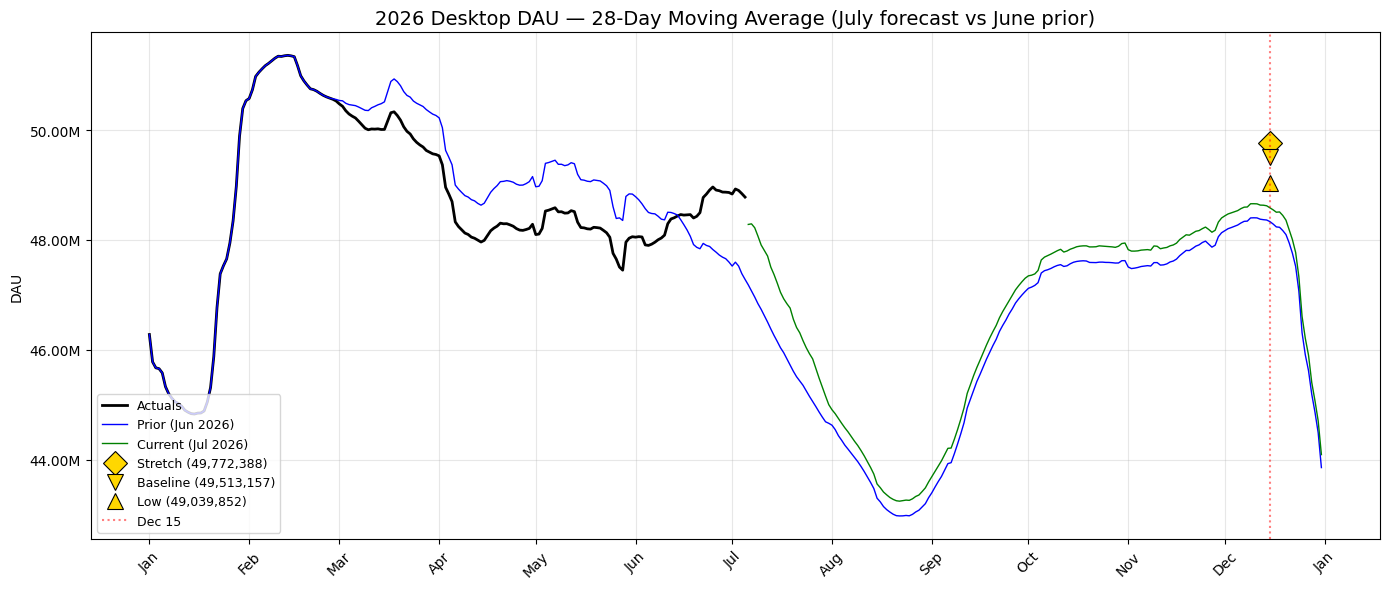

In [7]:
# [plot-desktop]
def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()

def clip_forecast_only(s, forecast_start=FORECAST_START):
    """Filter to forecast portion only within display window.

    forecast_start defaults to the desktop seam (FORECAST_START); pass
    MOBILE_FORECAST_START for the refreshed mobile curve so it blanks before the
    mobile seam (2026-07-06) rather than the desktop one (2026-06-29).
    """
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()

def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct (e.g. 16.50M vs 17.00M),
    # rather than collapsing to identical whole-million labels (16M / 16M / 17M).
    return f"{x / 1e6:.2f}M"

# Stakeholder Dec-15 benchmarks (reused from June; July targets TBD — see caveats cell)
STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388

def render_desktop_plot(*, show_prior: bool, title: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_desktop_ma), label="Prior (Jun 2026)", color="blue", linewidth=1)
    ax.plot(clip_forecast_only(desktop_ma), label="Current (Jul 2026)", color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

render_desktop_plot(show_prior=True,
                    title="2026 Desktop DAU — 28-Day Moving Average (July forecast vs June prior)")


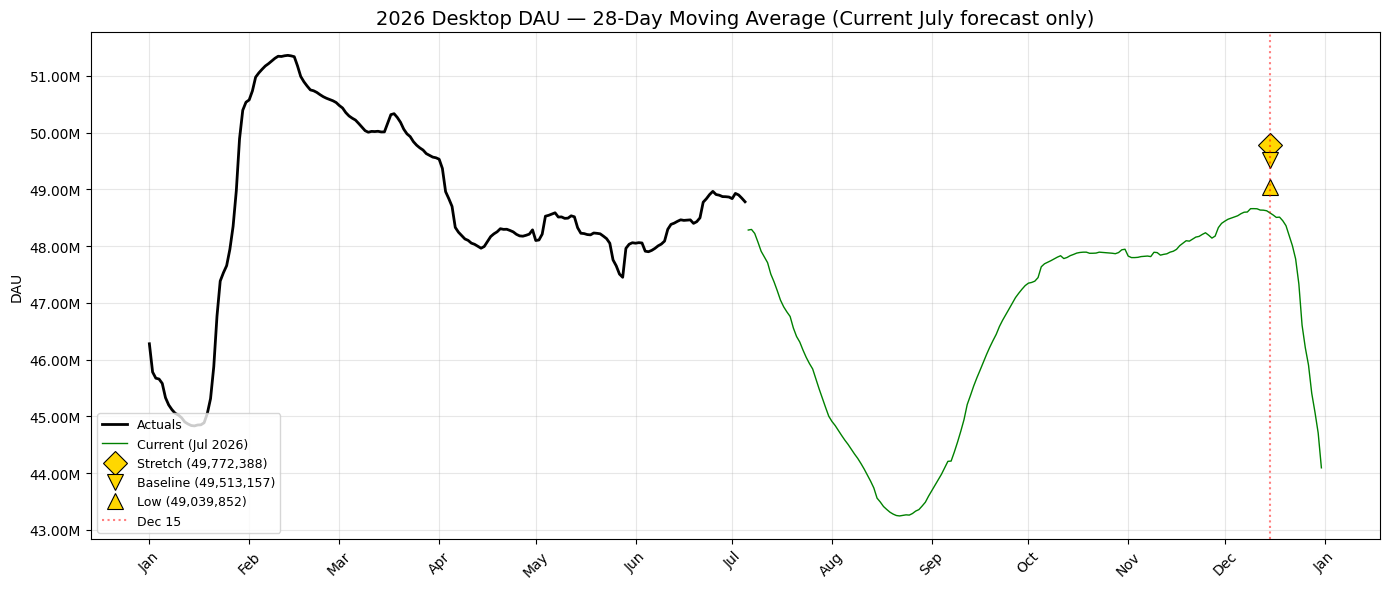

In [8]:
# [plot-desktop-no-april]
render_desktop_plot(show_prior=False,
                    title="2026 Desktop DAU — 28-Day Moving Average (Current July forecast only)")


In [9]:
# [desktop-dec15]
desktop_series = {
    "Actuals": desktop_actual_ma,
    "Prior (Jun 2026)": prev_desktop_ma,
    "Current (Jul 2026)": desktop_ma,
}

header = f"{'Series':<20s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in desktop_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<20s} {val_str:>18s}")


Series                 Dec 15 28-day MA
---------------------------------------
Actuals                             N/A
Prior (Jun 2026)             48,334,362
Current (Jul 2026)           48,585,483


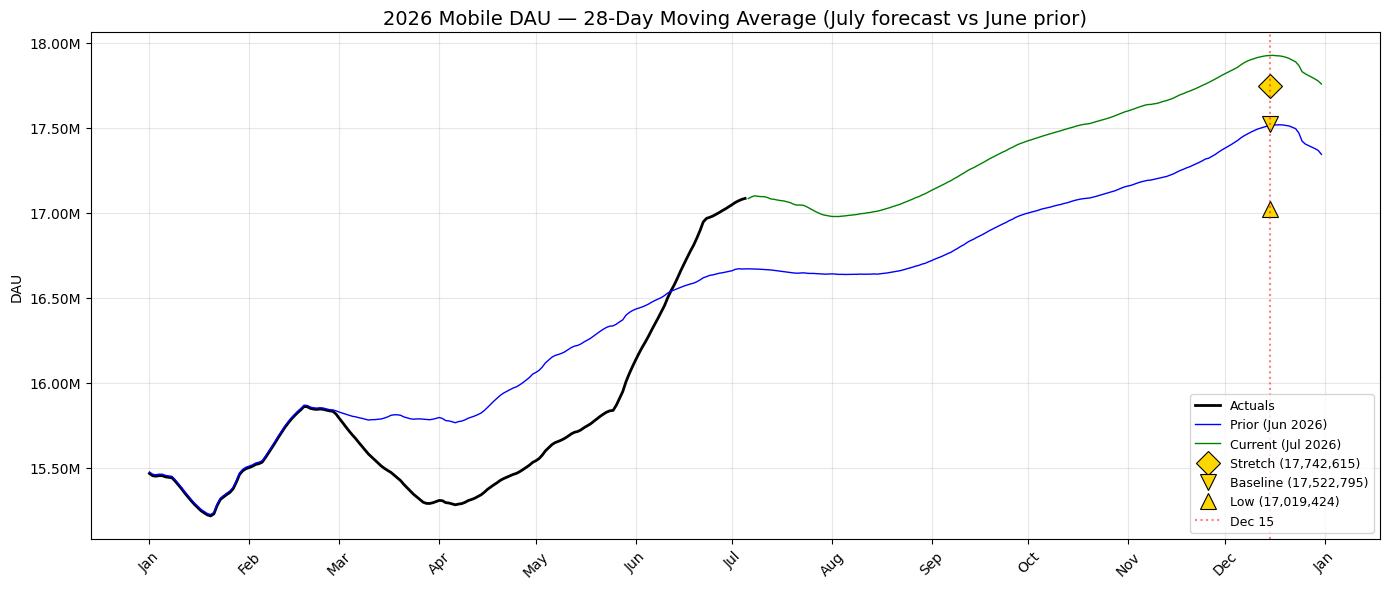

In [10]:
# [plot-mobile]
# Stakeholder Dec-15 mobile benchmarks (reused from June; July targets TBD — see caveats cell)
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615

def render_mobile_plot(*, show_prior: bool, title: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(mobile_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_mobile_ma), label="Prior (Jun 2026)", color="blue", linewidth=1)
    # Mobile was refreshed to the 2026-07-06 seam; blank the forecast before that.
    ax.plot(clip_forecast_only(mobile_ma, MOBILE_FORECAST_START), label="Current (Jul 2026)", color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

render_mobile_plot(show_prior=True,
                   title="2026 Mobile DAU — 28-Day Moving Average (July forecast vs June prior)")


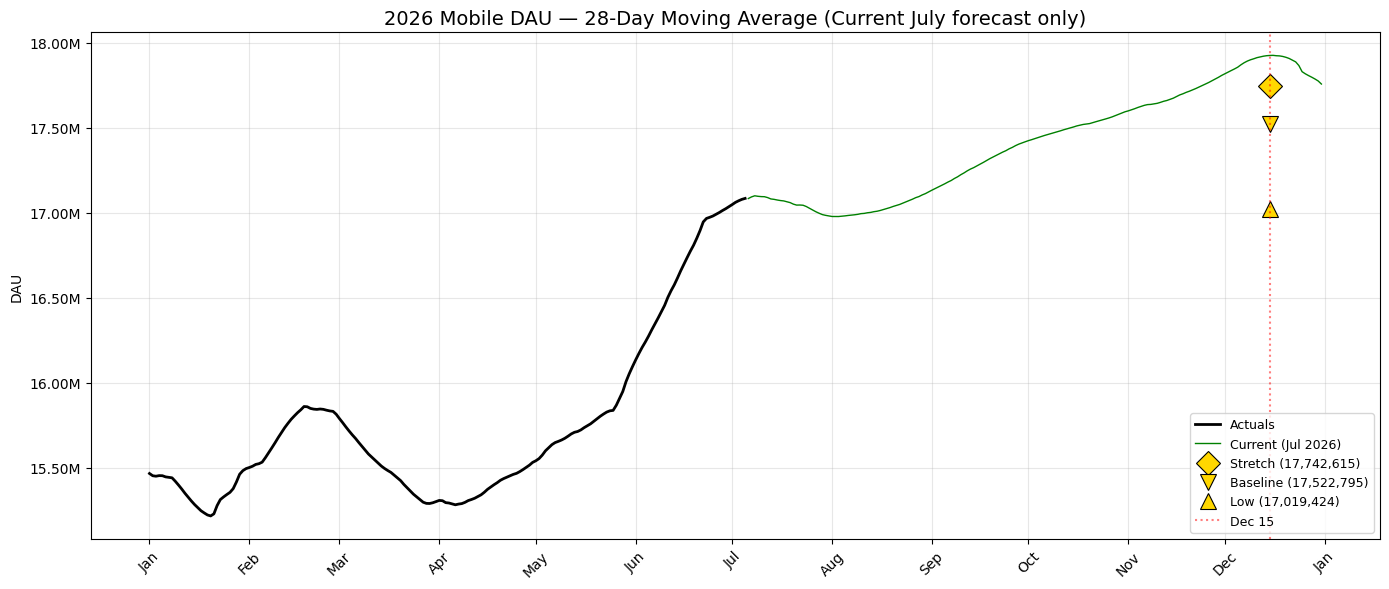

In [11]:
# [plot-mobile-no-april]
render_mobile_plot(show_prior=False,
                   title="2026 Mobile DAU — 28-Day Moving Average (Current July forecast only)")


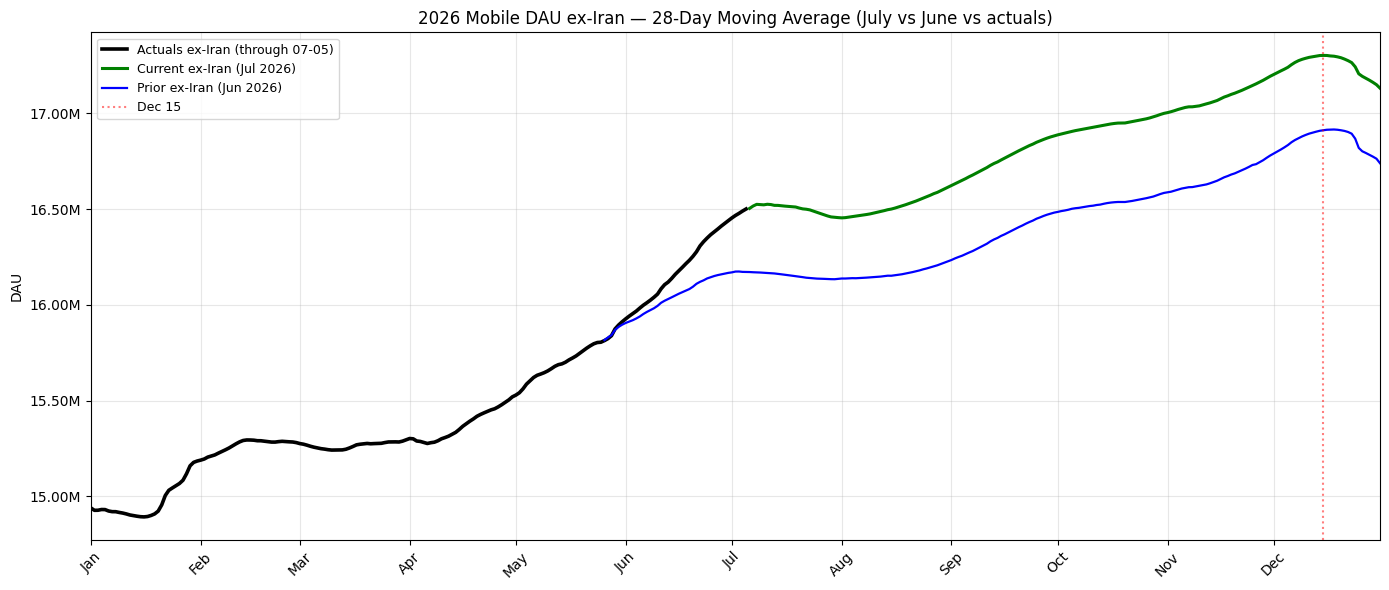

In [12]:
# [plot-mobile-ex-iran]
# ALL-MOBILE EXCLUDING Iran (28d MA): July forecast vs June forecast vs actuals.
# Removing Iran strips the reconnection-bounce noise so the underlying trajectories
# are directly comparable. Iran itself is still in the headline (incl-Iran) curves above.
# Mobile is the refreshed standalone parquet at MOBILE_FORECAST_START=2026-07-06 (trained
# through 2026-07-05), so the seam and the actuals cutoff both sit at the mobile date.
import matplotlib.ticker as mticker

_fc = pd.read_parquet(MOBILE_FORECAST_PATH)
_fc["target_date"] = pd.to_datetime(_fc["target_date"])
def _mob(country, dt=None):
    m = ((_fc.data_source == "glean_mobile") & (_fc.country == country)
         & (_fc.app_name == "ALL MOBILE") & (_fc.segment == "{}"))
    x = _fc.loc[m]
    if dt is not None:
        x = x[x.data_type == dt]
    return x.set_index("target_date").sort_index()["dau"]

SEAM = MOBILE_FORECAST_START - pd.Timedelta(days=1)   # 2026-07-05, last actual day

# July ex-Iran = ALL - IR (training+forecast), seam-smoothed MA + mobile headwind.
# display_ma / daily_to_28ma expect Series args (they call .values internally).
jul_exir = _mob("ALL").subtract(_mob("IR"), fill_value=0.0)
jul_exir_ma = apply_net_adjustment(display_ma(jul_exir.index.to_series(), jul_exir, MOBILE_FORECAST_START),
                                   net_adjustments, "mobile", forecast_start=MOBILE_FORECAST_START)
# Actuals ex-Iran = training rows (ALL - IR), plain 28d MA.
act_exir = _mob("ALL", "training").subtract(_mob("IR", "training"), fill_value=0.0)
act_exir_ma = daily_to_28ma(act_exir.index.to_series(), act_exir)
# June ex-Iran = the delivered June no-Iran curve (already 28d MA + June headwind, forecast-only).
_jc = pd.read_csv("data-official/2026-06/csv/june_canonical_curves.csv", parse_dates=["date"]).set_index("date")
june_exir_ma = _jc["mobile_current_june_no_iran"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(act_exir_ma.loc[DISPLAY_START:SEAM].index, act_exir_ma.loc[DISPLAY_START:SEAM],
        color="black", linewidth=2.6, label="Actuals ex-Iran (through 07-05)")
ax.plot(jul_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END].index, jul_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END],
        color="green", linewidth=2.2, label="Current ex-Iran (Jul 2026)")
ax.plot(june_exir_ma.loc[DISPLAY_START:DISPLAY_END].index, june_exir_ma.loc[DISPLAY_START:DISPLAY_END],
        color="blue", linewidth=1.6, label="Prior ex-Iran (Jun 2026)")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.set_title("2026 Mobile DAU ex-Iran — 28-Day Moving Average (July vs June vs actuals)")
ax.set_ylabel("DAU")
ax.set_xlim(DISPLAY_START, DISPLAY_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# [mobile-dec15]
mobile_series = {
    "Actuals": mobile_actual_ma,
    "Prior (Jun 2026)": prev_mobile_ma,
    "Current (Jul 2026)": mobile_ma,
}

header = f"{'Series':<20s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in mobile_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<20s} {val_str:>18s}")


Series                 Dec 15 28-day MA
---------------------------------------
Actuals                             N/A
Prior (Jun 2026)             17,511,100
Current (Jul 2026)           17,923,869


In [14]:
# [june-vs-targets]
# Compare each July forecast's Dec-15 28dMA against the stakeholder low/baseline/stretch targets
# (reused from June). Gap = forecast - target (positive => forecast exceeds the target).
forecast_rows = [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_DESKTOP_LOW, STAKEHOLDER_DESKTOP_BASELINE, STAKEHOLDER_DESKTOP_STRETCH),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE, np.nan),
     STAKEHOLDER_MOBILE_LOW, STAKEHOLDER_MOBILE_BASELINE, STAKEHOLDER_MOBILE_STRETCH),
]

def target_cell(forecast_value, target):
    return f"{target:,.0f} ({forecast_value - target:+,.0f})"

label_w = max(len(name) for name, *_ in forecast_rows)
fc_w = max(len("Forecast"), max(len(f"{fc:,.0f}") for _, fc, *_ in forecast_rows))
gap_w = max(
    len("Stretch (gap)"),
    max(len(target_cell(fc, t)) for _, fc, *targets in forecast_rows for t in targets),
)

print("July 2026 forecast vs stakeholder targets — Dec 15, 2026 28-day MA")
print("(gap = forecast - target; positive => forecast above target)")
print()
header = (f"{'Series':<{label_w}}  {'Forecast':>{fc_w}}  "
          f"{'Low (gap)':>{gap_w}}  {'Baseline (gap)':>{gap_w}}  {'Stretch (gap)':>{gap_w}}")
print(header)
print("-" * len(header))
for name, fc, low, base, stretch in forecast_rows:
    print(f"{name:<{label_w}}  {fc:>{fc_w},.0f}  "
          f"{target_cell(fc, low):>{gap_w}}  {target_cell(fc, base):>{gap_w}}  "
          f"{target_cell(fc, stretch):>{gap_w}}")


July 2026 forecast vs stakeholder targets — Dec 15, 2026 28-day MA
(gap = forecast - target; positive => forecast above target)

Series     Forecast                Low (gap)           Baseline (gap)            Stretch (gap)
----------------------------------------------------------------------------------------------
Desktop  48,585,483    49,039,852 (-454,369)    49,513,157 (-927,674)  49,772,388 (-1,186,905)
Mobile   17,923,869    17,019,424 (+904,445)    17,522,795 (+401,074)    17,742,615 (+181,254)


In [15]:
# [slack-summary]
# Slack-friendly Dec-15 28dMA table for the July forecast. Wrap in triple backticks in Slack.
rows = [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE, np.nan)),
]

label_width = max(len(name) for name, _ in rows)
value_width = max(len(f"{val:,.0f}") for _, val in rows)

print(f"July 2026 forecast — Dec 15, 2026 28-day MA")
print(f"{'Series':<{label_width}}  {'DAU':>{value_width}}")
print(f"{'-' * label_width}  {'-' * value_width}")
for name, val in rows:
    print(f"{name:<{label_width}}  {val:>{value_width},.0f}")


July 2026 forecast — Dec 15, 2026 28-day MA
Series          DAU
-------  ----------
Desktop  48,585,483
Mobile   17,923,869


In [16]:
# [slack-summary-compare]
# Side-by-side July vs June Dec-15 28dMA table for Slack.
rows = [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE, np.nan), prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE, np.nan), prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)),
]

label_width = max(len(name) for name, _, _ in rows)
july_col = "July-forecast DAU"
june_col = "June-forecast DAU"
july_width = max(len(july_col), max(len(f"{v:,.0f}") for _, v, _ in rows))
june_width = max(len(june_col), max(len(f"{v:,.0f}") for _, _, v in rows))

print(f"Dec 15, 2026 28-day MA")
print(f"{'Series':<{label_width}}  {july_col:>{july_width}}  {june_col:>{june_width}}")
print(f"{'-' * label_width}  {'-' * july_width}  {'-' * june_width}")
for name, july_val, june_val in rows:
    print(f"{name:<{label_width}}  {july_val:>{july_width},.0f}  {june_val:>{june_width},.0f}")


Dec 15, 2026 28-day MA
Series   July-forecast DAU  June-forecast DAU
-------  -----------------  -----------------
Desktop         48,585,483         48,334,362
Mobile          17,923,869         17,511,100


In [17]:
# [csv-export]
# Public-facing canonical curve exports (28d-MA, final KPI incl. headwind). BOTH platforms at the
# 2026-07-06 seam. Iran included natively (no plus/no-iran split this cycle). Rows = every day of 2026;
# `*_current_july` blank before the forecast seam, `*_actuals` blank after actuals end.
CSV_DIR = "data-official/2026-07/csv"
os.makedirs(CSV_DIR, exist_ok=True)
_idx = pd.date_range(DISPLAY_START, DISPLAY_END, freq="D")


def _col(series, forecast_start=None):
    s = series.reindex(_idx)
    if forecast_start is not None:            # current-forecast columns: blank before the seam
        s = s.where(s.index >= forecast_start)
    return s.values


frame = pd.DataFrame({"date": _idx.strftime("%Y-%m-%d")})
frame["desktop_actuals"] = _col(desktop_actual_ma)
frame["desktop_prior_june"] = _col(prev_desktop_ma)
frame["desktop_current_july"] = _col(desktop_ma, FORECAST_START)
frame["mobile_actuals"] = _col(mobile_actual_ma)
frame["mobile_prior_june"] = _col(prev_mobile_ma)
frame["mobile_current_july"] = _col(mobile_ma, MOBILE_FORECAST_START)
frame["all_actuals"] = frame["desktop_actuals"] + frame["mobile_actuals"]
frame["all_prior_june"] = frame["desktop_prior_june"] + frame["mobile_prior_june"]
frame["all_current_july"] = frame["desktop_current_july"] + frame["mobile_current_july"]
for c in frame.columns[1:]:
    frame[c] = frame[c].round(0)
curves_path = f"{CSV_DIR}/july_canonical_curves.csv"
frame.to_csv(curves_path, index=False)
print(f"wrote {curves_path}  ({len(frame)} rows x {len(frame.columns)} cols)")

# Dec-15 KPI summary CSV.
STAKEHOLDER = {"Desktop": 48_584_362, "Mobile": None, "ALL": None}
summary_rows = []
for name, cur, prev in [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE), prev_desktop_ma.get(MEASUREMENT_DATE)),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE), prev_mobile_ma.get(MEASUREMENT_DATE)),
    ("ALL", desktop_ma.get(MEASUREMENT_DATE) + mobile_ma.get(MEASUREMENT_DATE),
     prev_desktop_ma.get(MEASUREMENT_DATE) + prev_mobile_ma.get(MEASUREMENT_DATE)),
]:
    tgt = STAKEHOLDER[name]
    summary_rows.append({
        "series": name, "measurement_date": "2026-12-15",
        "current_july": round(cur), "prior_june": round(prev),
        "delta_vs_june": round(cur - prev),
        "target": tgt if tgt is not None else "",
        "vs_target": round(cur - tgt) if tgt is not None else "",
    })
summary = pd.DataFrame(summary_rows)
summary_path = f"{CSV_DIR}/july_dec15_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"wrote {summary_path}")
print(summary.to_string(index=False))


wrote data-official/2026-07/csv/july_canonical_curves.csv  (365 rows x 10 cols)
wrote data-official/2026-07/csv/july_dec15_summary.csv
 series measurement_date  current_july  prior_june  delta_vs_june   target vs_target
Desktop       2026-12-15      48585483    48334362         251121 48584362      1121
 Mobile       2026-12-15      17923869    17511100         412768                   
    ALL       2026-12-15      66509352    65845462         663890                   
